In [0]:
# verify the spark version:
print(spark.version)


4.0.0


# The folder including the datast can be found https://guscanada.sharepoint.com/:u:/s/DAMO630Winter2026/IQCC_z5c43WHToOR2k6ns2KiAdvZmLqlr4lccNAVJ3ZF5rc?e=pFrYV0

# ----------------------------
# Load groceries table
# ----------------------------

#The "functions" module imported in the next cell contains almost all DataFrame transformation functions in PySpark, such as:

F.col("name") – reference a column 

F.lit(5) – create a literal value

F.explode(array_col) – explode arrays into rows

F.count("*") – aggregate functions

F.sum("x"), F.avg("x"), F.max("x") – math/statistics

F.when(...).otherwise(...) – conditional logic

F.array, F.array_distinct, F.sort_array – array functions

F.struct, F.map, F.flatten – complex types

F.to_date, F.date_add, etc. – date/time functions


It includes hundreds of functions used to manipulate and process DataFrames.


In [0]:
from pyspark.sql import functions as F

TABLE_NAME = "damo630.default.grocery_data_5_m" # you may need to change the path here to where you saved the table
grocery_data = spark.table(TABLE_NAME) # here we defined a spark dataframe

display(grocery_data.limit(5))
grocery_data.printSchema()


Member_number,Date,itemDescription
24712,2015-09-20,rolls/buns
34753,2015-10-19,canned beer
34753,2015-10-19,white wine
25727,2015-09-12,organic vegetables
25727,2015-09-12,yogurt


root
 |-- Member_number: integer (nullable = true)
 |-- Date: date (nullable = true)
 |-- itemDescription: string (nullable = true)



# Visulaize the top most frequent items, for example top 20

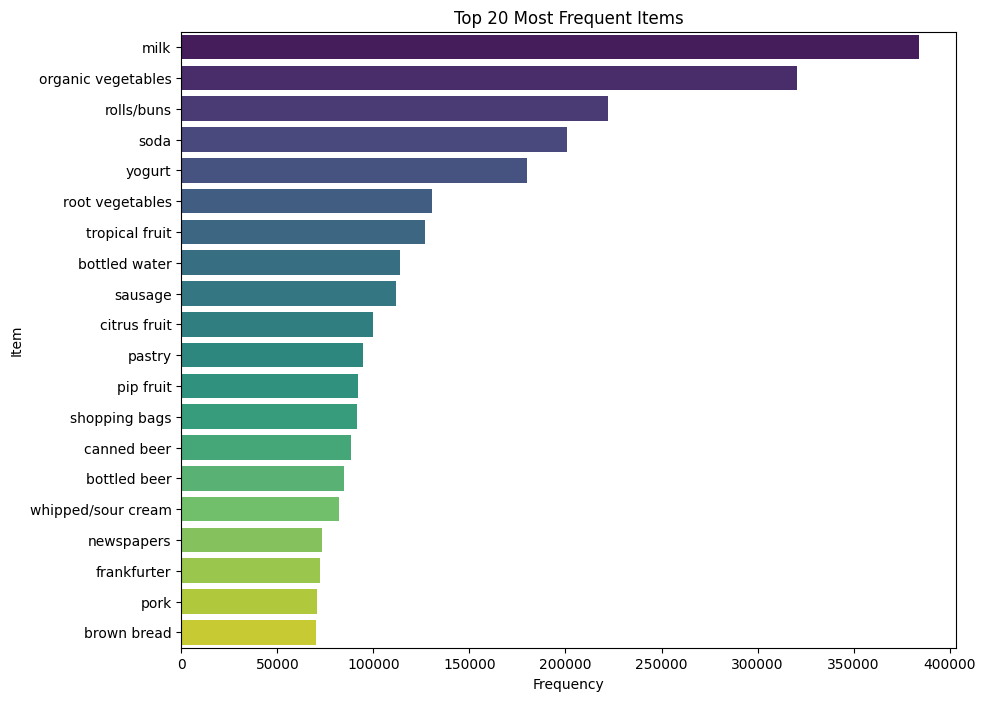

In [0]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

top_items = (
    grocery_data.groupBy("itemDescription")
    .count()
    .orderBy(F.col("count").desc())
    .limit(20)
    .toPandas()
)

plt.figure(figsize=(10,8))
sns.barplot(data=top_items, y="itemDescription", x="count", palette="viridis")
plt.title("Top 20 Most Frequent Items")
plt.xlabel("Frequency")
plt.ylabel("Item")
plt.show()


# ----------------------------
# 1) Data Preprocessing : Build transactions (baskets)
#    One transaction = one member on one date which is one order
# ----------------------------


In [0]:
transactions = (
    grocery_data .select(
        F.col("Member_number").alias("member"),
        F.col("Date").alias("date"),
        F.col("itemDescription").alias("item")
    )
    .filter(F.col("item").isNotNull())
    .groupBy("member", "date")
    .agg(F.collect_set("item").alias("items"))
    .filter(F.size("items") > 0)
)

n_tx = transactions.count()  # this counts how many transactions are in the dataset
print("Number of transactions (baskets):", n_tx)
display(transactions.limit(10))

Number of transactions (baskets): 391447


member,date,items
47163,2015-04-30,"List(pasta, pastry)"
27610,2015-11-27,"List(rolls/buns, salt)"
33160,2014-01-26,"List(pip fruit, organic vegetables)"
22811,2014-01-28,"List(milk, organic vegetables)"
16557,2014-06-18,"List(finished products, pet care, mayonnaise)"
21376,2015-09-12,"List(tropical fruit, organic vegetables)"
34508,2014-04-14,"List(brown bread, long life bakery product)"
34159,2014-09-03,"List(organic vegetables, beverages, chicken)"
41387,2014-07-12,"List(fruit/vegetable juice, soda)"
37787,2015-10-25,"List(whipped/sour cream, bottled beer)"


# Visualize basket size distribution

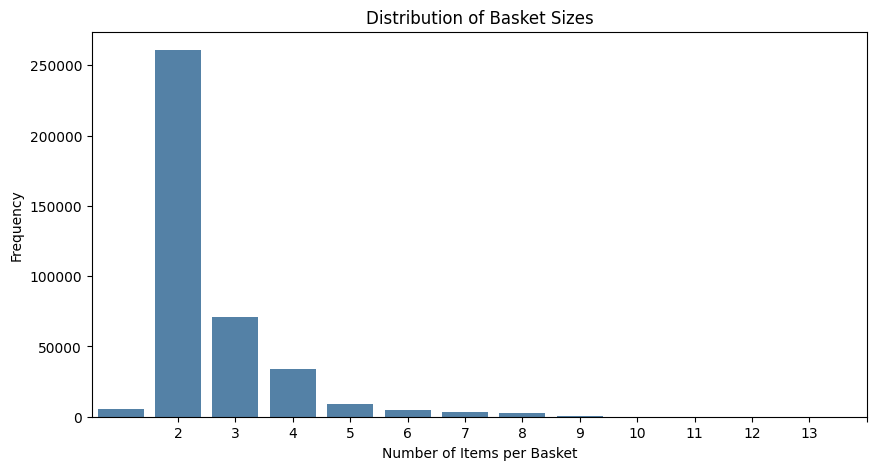

In [0]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Calculate basket size counts
basket_pd = (
    transactions
    .withColumn("basket_size", F.size("items"))
    .groupBy("basket_size")
    .count()
    .orderBy("basket_size")
    .toPandas()
)

plt.figure(figsize=(10,5))
sns.barplot(
    data=basket_pd,
    x="basket_size",
    y="count",
    color="steelblue"
)

plt.title("Distribution of Basket Sizes")
plt.xlabel("Number of Items per Basket")
plt.ylabel("Frequency")
plt.xticks(basket_pd["basket_size"])
plt.show()



# Display a plot showing the average basket size by day of week to look for any patterns

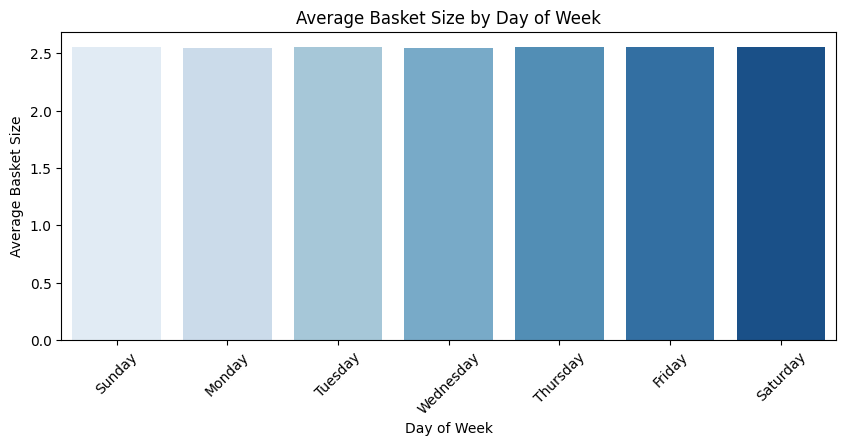

In [0]:

from pyspark.sql.functions import dayofweek

# Compute avg basket size by day of week
dow_df = (
    transactions
    .withColumn("basket_size", F.size("items"))
    .withColumn("dow", dayofweek("date"))
    .groupBy("dow")
    .agg(F.avg("basket_size").alias("avg_size"))
    .orderBy("dow")
    .toPandas()
)

# Map numbers → day names
day_map = {
    1: "Sunday",
    2: "Monday",
    3: "Tuesday",
    4: "Wednesday",
    5: "Thursday",
    6: "Friday",
    7: "Saturday"
}

dow_df["day_name"] = dow_df["dow"].map(day_map)

# Plot
plt.figure(figsize=(10,4))
sns.barplot(data=dow_df, x="day_name", y="avg_size", palette="Blues")
plt.title("Average Basket Size by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Basket Size")
plt.xticks(rotation=45)
plt.show()



# ----------------------------
## 2) Setting Apriori Algorithm Parameters 
# ----------------------------


## Support and Confidence Formulas for Frequent Itemsets

### **Support**
Support measures how frequently an itemset appears in the dataset, it is a re;ative frequency.

$$\[
\text{Support}(X) = \frac{\text{Number of transactions containing } X}{\text{Total number of transactions}}
\]$$

Where:
- \( X \) is an itemset (e.g., {bread, milk})
- Support is a value between 0 and 1

---

### **Confidence**
Confidence measures how often rule \( X ➡ Y \) is found to be true.

$$\[
\text{Confidence}(X \rightarrow Y) = \frac{\text{Support}(X \cup Y)}{\text{Support}(X)}
\]$$


Confidence indicates the probability that a transaction containing \( X \) also contains \( Y \) Where:
$$\( X \rightarrow Y\) \text {is an association rule} $$
$$\( X \cup Y \) \text {is the combined itemset}  $$


---

### **Example Interpretation**
- **Support({milk, bread}) = 0.2**  
  → 20% of all transactions contain both milk and bread.

- **Confidence({bread} → {milk}) = 0.6**  
  → When bread is purchased, milk is also purchased 60% of the time.


In [0]:
minSupport = 0.01      # you may change as needed
minConfidence = 0.10   # you may change as needed


# ----------------------------
# 3) Frequent 1-itemsets; this is phase 1 of the apriori algorthim
# ----------------------------

In [0]:

freq1 = (                           # note that freq1 is a Spark DataFrame
    transactions
    .select(F.explode("items").alias("item"))
    .groupBy("item")
    .count()
    .withColumn("support", F.col("count") / F.lit(n_tx))
)

freq1_f = freq1.where(F.col("support") >= minSupport) # this a smaple of freq1 where the support is greater than or equal to the minimum support threshold.

print("Number of Frequent 1-itemsets:", freq1_f.count())
display(freq1_f.orderBy(F.col("count").desc()).limit(30))

Number of Frequent 1-itemsets: 62


item,count,support
milk,76762,0.19609806691582768
organic vegetables,64017,0.16353938081017352
rolls/buns,44434,0.11351217406187811
soda,40110,0.10246597879150945
yogurt,36010,0.09199201935383335
root vegetables,26145,0.06679065109708339
tropical fruit,25353,0.06476738868863473
bottled water,22728,0.05806150002426893
sausage,22379,0.05716993615993991
citrus fruit,19902,0.05084213188503169


# ----------------------------
# 4) Frequent 2-itemsets (pairs)
#    Apriori k=2 counting
# ----------------------------

In [0]:

pairs = (                                   # note that pairs is a Spark dataframe                      
    transactions
    .withColumn("i", F.explode("items"))
    .withColumn("j", F.explode("items"))
    .where(F.col("i") < F.col("j"))   # unique unordered pairs
    .select("i", "j")
)

display(pairs.head(5))     # just to see a sample of this dataframe

freq2 = (
    pairs
    .groupBy("i", "j") # groups the DataFrame by the pair (i, j). All rows with the same item pair are put into the same group.
    .count()
    .withColumn("support", F.col("count") / F.lit(n_tx)) # Adds a new column called support by dividing the pair’s count by the total number of transactions n_tx. F.lit(n_tx) wraps the Python value n_tx as a Spark literal so division happens in Spark
)

freq2_f = freq2.where(F.col("support") >= minSupport) #selects the rows where the support is greater than or equal to the minimum support threshold.

print("Frequent 2-itemsets:", freq2_f.count())
display(freq2_f.orderBy(F.col("count").desc()).limit(50)) #50 is just a number of rows to display, you amy change it.

i,j
pasta,pastry
rolls/buns,salt
organic vegetables,pip fruit
milk,organic vegetables
finished products,pet care


Frequent 2-itemsets: 9


i,j,count,support
milk,organic vegetables,25060,0.06401888378247886
rolls/buns,soda,6944,0.017739310813469
rolls/buns,yogurt,6611,0.016888620937189455
soda,yogurt,6228,0.01591019984825532
milk,rolls/buns,5907,0.015090165463012872
milk,soda,5309,0.013562500159664016
milk,yogurt,4847,0.012382263754735634
organic vegetables,rolls/buns,4703,0.012014397862290424
organic vegetables,soda,4072,0.01040242995858954


# ----------------------------
# 5) Association rules from pairs, this is phase 2 of the apriori algorthim
#    i -> j and j -> i
#    confidence(A->B) = support(A,B)/support(A)
#    lift(A->B) = confidence(A->B) / support(B)
# ----------------------------

The next cell preparse freq1 for joining

Why two versions?

We need two different column names for joins:

In rules i → j:

join freq1 on i for count/support of the antecedent
join freq1 on j for the support of the consequent

So:

freq1_stats gives:
x = item, cnt_x = count, sup_x = support
→ used for antecedent statistics



In [0]:
# For joins
freq1_stats = freq1.select(
    F.col("item").alias("x"),
    F.col("count").alias("cnt_x"),
    F.col("support").alias("sup_x")
)

freq1_support = freq1.select(
    F.col("item").alias("y"),
    F.col("support").alias("sup_y")
)

Next cell builds rules of the form i → j

Step 1 — Join with freq1 for antecedent stats

  freq2_f.i == freq1_stats.x

→ gets count and support of item i

 Step 2 — Join with freq1 for consequent stats
  freq2_f.j == freq1_support.y

  → gets support of item j



In [0]:
# i -> j
rules_ij = (
    freq2_f
    .join(freq1_stats, freq2_f.i == freq1_stats.x, "left") # this joins with freq1_stats (for antecedent stats), note that the freq1_stats contains x = item, cnt_x = frequency of x, sup_x = support(x) and freq2_f df contains i – first item, j – second item, count –                                                       number of transactions containing both support – support(i,j)
    .join(freq1_support, freq2_f.j == freq1_support.y, "left") # Add support of the consequent (j)
    .withColumn("confidence", F.col("count") / F.col("cnt_x"))# Compute Confidence
    .withColumn("lift", F.col("confidence") / F.col("sup_y")) # Compute Lift
    .select(
        F.col("i").alias("antecedent"),
        F.col("j").alias("consequent"),
        F.col("count").alias("pair_count"),
        "support",
        "confidence",
        "lift"
    )
)


    

# j -> i
rules_ji = (
    freq2_f
    .join(freq1_stats, freq2_f.j == freq1_stats.x, "left")
    .join(freq1_support, freq2_f.i == freq1_support.y, "left")
    .withColumn("confidence", F.col("count") / F.col("cnt_x"))
    .withColumn("lift", F.col("confidence") / F.col("sup_y"))
    .select(
        F.col("j").alias("antecedent"),
        F.col("i").alias("consequent"),
        F.col("count").alias("pair_count"),
        "support",
        "confidence",
        "lift"
    )
)

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-6552782428990751>, line 3
      1 # i -> j
      2 rules_ij = (
----> 3     freq2_f
      4     .join(freq1_stats, freq2_f.i == freq1_stats.x, "left") # this joins with freq1_stats (for antecedent stats), note that the freq1_stats contains x = item, cnt_x = frequency of x, sup_x = support(x) and freq2_f df contains i – first item, j – second item, count –                                                       number of transactions containing both support – support(i,j)
      5     .join(freq1_support, freq2_f.j == freq1_support.y, "left") # Add support of the consequent (j)
      6     .withColumn("confidence", F.col("count") / F.col("cnt_x"))# Compute Confidence
      7     .withColumn("lift", F.col("confidence") / F.col("sup_y")) # Compute Lift
      8     .select(
      9         F.col("i").alias("antecedent"),
     10 

#Combine rules going in both directions
We have two rule directions for each frequent item pair:

rules_ij → rules of the form X → Y

rules_ji → rules of the form Y → X

In [0]:
rules = (
    rules_ij.unionByName(rules_ji)     # combining the two rules_ij and rules_ji
    .where(F.col("confidence") >= minConfidence)  # filtering by minimum confidence
    .orderBy(F.col("confidence").desc(), F.col("lift").desc())
)

print("Rules (after minConfidence):", rules.count())
display(rules.limit(50))

# ----------------------------
# 6) Show top rules by lift
# ----------------------------


What is Lift?

Lift measures whether X and Y occur together more often than expected **by chance**.

$$\[
\text{Lift}(X \rightarrow Y) =
\frac{\text{Support}(X \cup Y)}
{\text{Support}(X) \cdot \text{Support}(Y)}
\]$$

### **Lift Interpretation**
- **Lift > 1** → X and Y appear together **more than expected** (positive association)  
- **Lift = 1** → X and Y are **independent** (no association)  
- **Lift < 1** → X and Y appear together **less than expected** (negative association)

### **Example**  
Let’s use:

- Support(bread ∪ milk) = 0.18  
- Support(bread) = 0.40  
- Support(milk) = 0.30  

$$\[
\text{Lift(bread → milk)} =
\frac{0.18}{0.40 \times 0.30}
= \frac{0.18}{0.12}
= 1.5
\]$$

**Interpretation:**  
Lift = 1.5 means customers who buy bread are **50% more likely** to buy milk than expected if the items were independent.  
This makes the rule *strong and meaningful*, which is why sorting by lift is common.

---


## ✅ Note the following

| Metric        | What It Measures                       | Also Known As | Interpretation |
|---------------|------------------------------------------|----------------|----------------|
| **Support**   | Frequency of an itemset in the dataset   | Prevalence     | Higher = itemset appears frequently |
| **Confidence**| Probability of Y given X (X → Y rule)     | Accuracy       | Higher = rule is more reliable |
| **Lift**      | How much more likely X & Y occur together vs. chance | — | >1 positive association, =1 none, <1 negative |




In [0]:
display(rules.orderBy(F.col("lift").desc()).limit(50))


antecedent,consequent,pair_count,support,confidence,lift
organic vegetables,milk,25060,0.06401888378247886,0.3914585188309355,1.9962385401736955
milk,organic vegetables,25060,0.06401888378247886,0.3264636148094109,1.9962385401736955
soda,yogurt,6228,0.01591019984825532,0.15527299925205684,1.6878964103921104
yogurt,soda,6228,0.01591019984825532,0.17295195778950292,1.6878964103921104
yogurt,rolls/buns,6611,0.016888620937189455,0.1835878922521522,1.6173409924478601
rolls/buns,yogurt,6611,0.016888620937189455,0.14878246387901156,1.61734099244786
rolls/buns,soda,6944,0.017739310813469,0.15627672503038215,1.5251571972816753
soda,rolls/buns,6944,0.017739310813469,0.1731239092495637,1.5251571972816753
yogurt,milk,4847,0.012382263754735634,0.13460149958344905,0.6863989110164194
rolls/buns,milk,5907,0.015090165463012872,0.13293874060404196,0.6779196893414764



## How Lift Is Used to Promote Sales

Lift measures how much more likely two items are purchased together compared to chance. Lift identifies true product associations that retailers can leverage to increase cross‑selling, optimize promotions, and grow revenue.
 
Retailers use high‑lift item pairs to design sales strategies:

### **1. Product Bundling**
High-lift pairs are combined in promotions (e.g., "Buy X, get Y 10% off") to increase basket size.

### **2. Product Placement**
Items with strong lift are placed near each other in stores or displays to drive impulse purchases.

### **3. Targeted Discounts**
Discounting one item in a high-lift pair boosts sales of the other, improving promotion ROI.

### **4. Personalized Recommendations**
E‑commerce uses lift to show “Frequently Bought Together,” increasing add‑on purchases.

### **5. Seasonal Promotions**
High-lift relationships guide combined seasonal campaigns (e.g., chips + salsa during sports events).

### **6. Inventory Planning**
Lift helps forecast related-product demand (e.g., diapers → baby wipes), preventing stockouts.

---